========== PERFIL BASE ABRIL ==========
Energía diaria sin ajuste: 2.8680 kWh/día
Energía diaria objetivo:   2.8667 kWh/día
Factor de ajuste aplicado: 0.999535
Energía diaria final:      2.8667 kWh/día
Energía mensual abril:     86.00 kWh/mes
Peak abril:                0.797 kW

Perfil horario abril:
    hora      P_kW
0      0  0.096955
1      1  0.096955
2      2  0.096955
3      3  0.096955
4      4  0.096955
5      5  0.096955
6      6  0.096955
7      7  0.220231
8      8  0.066969
9      9  0.066969
10    10  0.066969
11    11  0.066969
12    12  0.066969
13    13  0.066969
14    14  0.066969
15    15  0.113614
16    16  0.066969
17    17  0.076964
18    18  0.076964
19    19  0.076964
20    20  0.796629
21    21  0.096955
22    22  0.096955
23    23  0.096955

Energía día minutal abril:
2.866666666666667

========== RESUMEN MENSUAL ==========
    mes         Mes  Dias  Multiplicador  E_dia_prom_kWh  E_mes_kWh  \
0     1       Enero    31            1.4           4.013    124.413

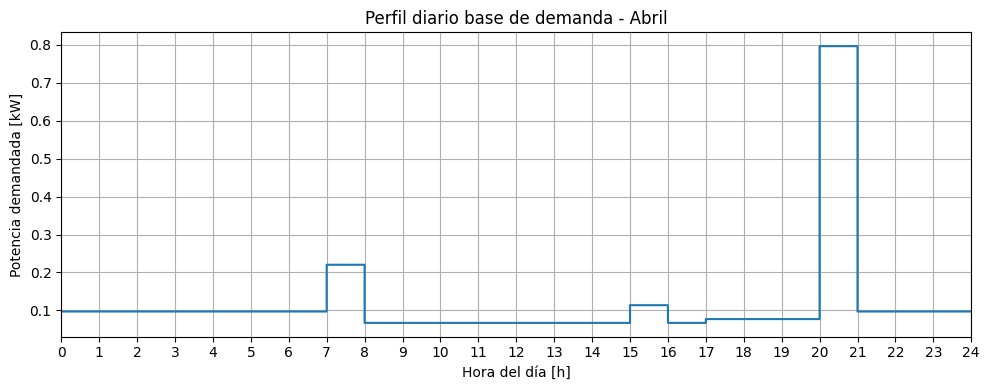

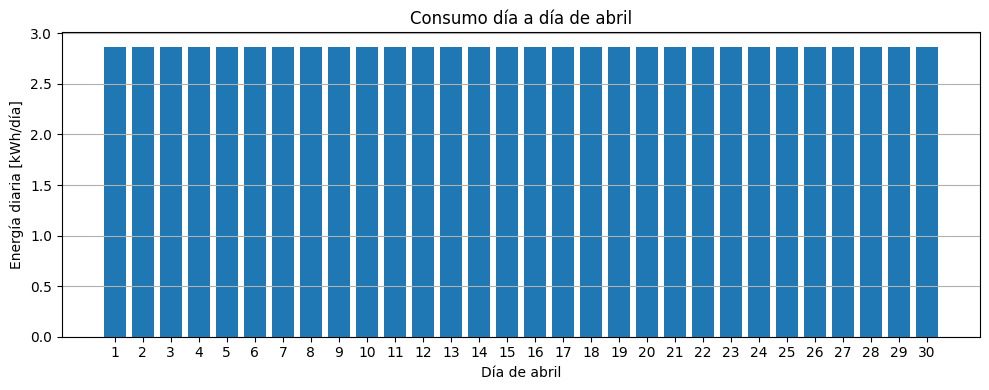

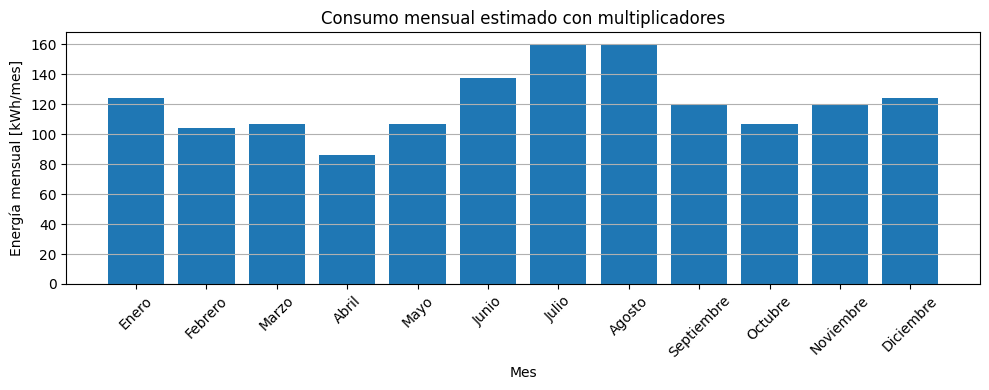

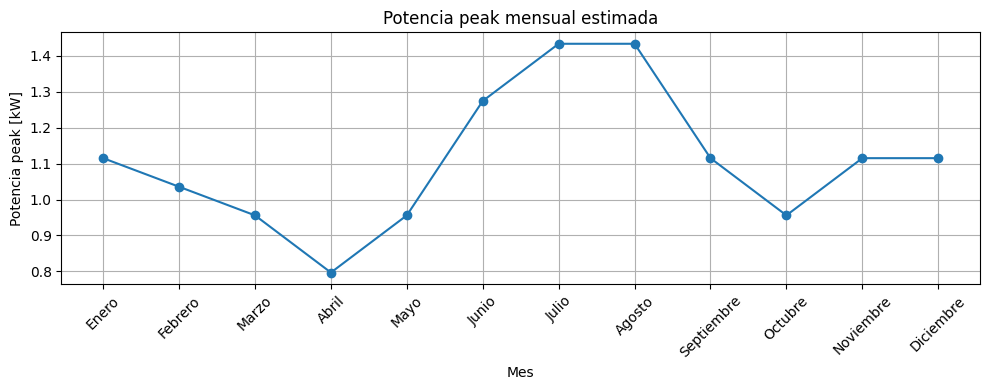

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. DATOS GENERALES
# ============================================================

# Consumo objetivo de abril según boleta
consumo_abril_kwh = 86
dias_abril = 30
energia_dia_objetivo = consumo_abril_kwh / dias_abril

# Meses, días y multiplicadores definidos
meses = {
    1:  {"nombre": "Enero",      "dias": 31, "mult": 1.4},
    2:  {"nombre": "Febrero",    "dias": 28, "mult": 1.3},
    3:  {"nombre": "Marzo",      "dias": 31, "mult": 1.2},
    4:  {"nombre": "Abril",      "dias": 30, "mult": 1.0},
    5:  {"nombre": "Mayo",       "dias": 31, "mult": 1.2},
    6:  {"nombre": "Junio",      "dias": 30, "mult": 1.6},
    7:  {"nombre": "Julio",      "dias": 31, "mult": 1.8},
    8:  {"nombre": "Agosto",     "dias": 31, "mult": 1.8},
    9:  {"nombre": "Septiembre", "dias": 30, "mult": 1.4},
    10: {"nombre": "Octubre",    "dias": 31, "mult": 1.2},
    11: {"nombre": "Noviembre",  "dias": 30, "mult": 1.4},
    12: {"nombre": "Diciembre",  "dias": 31, "mult": 1.4},
}

# ============================================================
# 2. POTENCIAS REFERENCIALES DE EQUIPOS [kW]
# ============================================================

P_refrigerador = 0.055      # 55 W promedio
P_wifi = 0.010              # 10 W
P_tv_standby = 0.002        # 2 W
P_cargador = 0.010          # 10 W por cargador activo
P_led = 0.010               # 10 W por ampolleta LED
P_tostador = 0.800          # 800 W
P_cocina = 1.200            # 1200 W
P_hervidor = 1.800          # 1800 W
P_microondas = 1.000        # 1000 W
P_airfryer = 1.400          # 1400 W

# Carga base que funciona todo el día
P_base = P_refrigerador + P_wifi + P_tv_standby

# ============================================================
# 3. PERFIL HORARIO BASE DE ABRIL
# ============================================================

# Inicializar todas las horas con carga base
perfil_horario = pd.DataFrame({
    "hora": np.arange(24),
    "P_kW": np.ones(24) * P_base
})

# 00:00 a 06:00 -> base + 3 cargadores
perfil_horario.loc[perfil_horario["hora"].between(0, 6), "P_kW"] += 3 * P_cargador

# 07:00 -> tostador 1 min + cocina 4 min + hervidor 2 min
perfil_horario.loc[perfil_horario["hora"] == 7, "P_kW"] += (
    P_tostador * (1/60) +
    P_cocina * (4/60) +
    P_hervidor * (2/60)
)

# 15:00 -> 3 cargadores + microondas 1 min
perfil_horario.loc[perfil_horario["hora"] == 15, "P_kW"] += (
    3 * P_cargador +
    P_microondas * (1/60)
)

# 17:00 a 19:00 -> 1 cargador
perfil_horario.loc[perfil_horario["hora"].between(17, 19), "P_kW"] += P_cargador

# 20:00 -> 2 luces LED + cargador + air fryer 30 min
perfil_horario.loc[perfil_horario["hora"] == 20, "P_kW"] += (
    2 * P_led +
    P_cargador +
    P_airfryer * (30/60)
)

# 21:00 a 23:00 -> luz + cargador
# Se asume que "luz" corresponde a 2 ampolletas LED, igual que a las 20:00
perfil_horario.loc[perfil_horario["hora"].between(21, 23), "P_kW"] += (
    2 * P_led +
    P_cargador
)

# ============================================================
# 4. AJUSTE PARA QUE ABRIL SEA EXACTAMENTE 86 kWh/MES
# ============================================================

energia_dia_sin_ajuste = perfil_horario["P_kW"].sum()
factor_ajuste = energia_dia_objetivo / energia_dia_sin_ajuste

perfil_horario["P_kW"] = perfil_horario["P_kW"] * factor_ajuste

# Restricción de peak máximo de 8 kW
perfil_horario["P_kW"] = perfil_horario["P_kW"].clip(upper=8)

energia_dia_abril = perfil_horario["P_kW"].sum()
energia_mes_abril = energia_dia_abril * dias_abril

print("========== PERFIL BASE ABRIL ==========")
print(f"Energía diaria sin ajuste: {energia_dia_sin_ajuste:.4f} kWh/día")
print(f"Energía diaria objetivo:   {energia_dia_objetivo:.4f} kWh/día")
print(f"Factor de ajuste aplicado: {factor_ajuste:.6f}")
print(f"Energía diaria final:      {energia_dia_abril:.4f} kWh/día")
print(f"Energía mensual abril:     {energia_mes_abril:.2f} kWh/mes")
print(f"Peak abril:                {perfil_horario['P_kW'].max():.3f} kW")

print("\nPerfil horario abril:")
print(perfil_horario)

# ============================================================
# 5. PERFIL MINUTAL DE UN DÍA TIPO DE ABRIL
# ============================================================

perfil_minutal_abril = pd.DataFrame({
    "minuto_dia": np.arange(1440),
    "hora": np.repeat(np.arange(24), 60),
    "P_demanda_kW": np.repeat(perfil_horario["P_kW"].values, 60)
})

perfil_minutal_abril["tiempo_h"] = perfil_minutal_abril["minuto_dia"] / 60
perfil_minutal_abril["E_kWh"] = perfil_minutal_abril["P_demanda_kW"] / 60

print("\nEnergía día minutal abril:")
print(perfil_minutal_abril["E_kWh"].sum())

# ============================================================
# 6. PERFIL ANUAL MINUTAL CON MULTIPLICADORES MENSUALES
# ============================================================

# Año no bisiesto
fechas = pd.date_range(
    start="2026-01-01 00:00",
    end="2026-12-31 23:59",
    freq="min"
)

df_anual = pd.DataFrame(index=fechas)
df_anual["mes"] = df_anual.index.month
df_anual["dia"] = df_anual.index.day
df_anual["hora"] = df_anual.index.hour
df_anual["minuto"] = df_anual.index.minute

# Mapear potencia horaria base de abril
mapa_potencia_hora = dict(zip(perfil_horario["hora"], perfil_horario["P_kW"]))
df_anual["P_base_abril_kW"] = df_anual["hora"].map(mapa_potencia_hora)

# Mapear multiplicadores mensuales
mapa_multiplicadores = {m: datos["mult"] for m, datos in meses.items()}
mapa_nombres = {m: datos["nombre"] for m, datos in meses.items()}

df_anual["multiplicador"] = df_anual["mes"].map(mapa_multiplicadores)
df_anual["nombre_mes"] = df_anual["mes"].map(mapa_nombres)

# Demanda final anual
df_anual["P_demanda_kW"] = df_anual["P_base_abril_kW"] * df_anual["multiplicador"]

# Aplicar límite de 8 kW por seguridad
df_anual["P_demanda_kW"] = df_anual["P_demanda_kW"].clip(upper=8)

# Energía por minuto
df_anual["E_kWh"] = df_anual["P_demanda_kW"] / 60

# ============================================================
# 7. RESUMEN MENSUAL
# ============================================================

resumen_mensual = (
    df_anual
    .groupby("mes")
    .agg(
        E_mes_kWh=("E_kWh", "sum"),
        P_prom_kW=("P_demanda_kW", "mean"),
        P_peak_kW=("P_demanda_kW", "max")
    )
    .reset_index()
)

resumen_mensual["Mes"] = resumen_mensual["mes"].map(mapa_nombres)
resumen_mensual["Multiplicador"] = resumen_mensual["mes"].map(mapa_multiplicadores)
resumen_mensual["Dias"] = resumen_mensual["mes"].map({m: datos["dias"] for m, datos in meses.items()})
resumen_mensual["E_dia_prom_kWh"] = resumen_mensual["E_mes_kWh"] / resumen_mensual["Dias"]

resumen_mensual = resumen_mensual[
    ["mes", "Mes", "Dias", "Multiplicador", "E_dia_prom_kWh", "E_mes_kWh", "P_prom_kW", "P_peak_kW"]
]

print("\n========== RESUMEN MENSUAL ==========")
print(resumen_mensual.round(3))

energia_anual = resumen_mensual["E_mes_kWh"].sum()
print(f"\nConsumo anual total: {energia_anual:.2f} kWh/año")

# ============================================================
# 8. GRÁFICO 1: PERFIL DIARIO DE ABRIL
# ============================================================

plt.figure(figsize=(10, 4))
plt.step(
    perfil_minutal_abril["tiempo_h"],
    perfil_minutal_abril["P_demanda_kW"],
    where="post"
)
plt.xlabel("Hora del día [h]")
plt.ylabel("Potencia demandada [kW]")
plt.title("Perfil diario base de demanda - Abril")
plt.grid(True)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 1))
plt.tight_layout()
plt.show()

# ============================================================
# 9. GRÁFICO 2: ENERGÍA DÍA A DÍA DE ABRIL
# ============================================================

df_abril = df_anual[df_anual["mes"] == 4].copy()

energia_diaria_abril = (
    df_abril
    .resample("D")["E_kWh"]
    .sum()
)

plt.figure(figsize=(10, 4))
plt.bar(energia_diaria_abril.index.day, energia_diaria_abril.values)
plt.xlabel("Día de abril")
plt.ylabel("Energía diaria [kWh/día]")
plt.title("Consumo día a día de abril")
plt.grid(True, axis="y")
plt.xticks(np.arange(1, 31, 1))
plt.tight_layout()
plt.show()

# ============================================================
# 10. GRÁFICO 3: CONSUMO MENSUAL
# ============================================================

plt.figure(figsize=(10, 4))
plt.bar(resumen_mensual["Mes"], resumen_mensual["E_mes_kWh"])
plt.xlabel("Mes")
plt.ylabel("Energía mensual [kWh/mes]")
plt.title("Consumo mensual estimado con multiplicadores")
plt.grid(True, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 11. GRÁFICO 4: POTENCIA PEAK MENSUAL
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(resumen_mensual["Mes"], resumen_mensual["P_peak_kW"], marker="o")
plt.xlabel("Mes")
plt.ylabel("Potencia peak [kW]")
plt.title("Potencia peak mensual estimada")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()